# Dataloader

In [2]:
import argparse
import inspect
import logging
import math
import os
import shutil
from datetime import timedelta
from pathlib import Path

import datasets
from datasets import load_dataset
import torch
import torch.nn.functional as F
from torchvision import transforms


/media/aris/Data/master2025dev/aris_master/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_data_dir = "/media/aris/Data/master2025dev/datasets/wood/4_main_categories"

dataset = load_dataset("imagefolder", data_dir=train_data_dir, split="train")

In [4]:
len(dataset)
print(dataset)
png_image = dataset[0]['image']
# Extract image shape
print(png_image.size)  # Output: (width, height)

Dataset({
    features: ['image'],
    num_rows: 5954
})
(1920, 1200)


In [5]:
num_workers = os.cpu_count() // 2 # Use half of available CPU cores
batch_size = 16
# --- Basic image augmentations --- #
# VAE Resolution
resolution = 512
center_crop = True
random_flip = True

In [ ]:
# Preprocessing the datasets and DataLoaders creation.
spatial_augmentations = [
    transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(resolution) if center_crop else transforms.RandomCrop(resolution),
    transforms.RandomHorizontalFlip() if random_flip else transforms.Lambda(lambda x: x),
]

augmentations = transforms.Compose(
    spatial_augmentations
    + [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)


def transform_images(examples):
    processed = []
    for image in examples["image"]:
        processed.append(augmentations(image.convert("RGB")))

    return {"input": processed}


dataset.set_transform(transform_images)
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

In [10]:
print(train_dataloader)

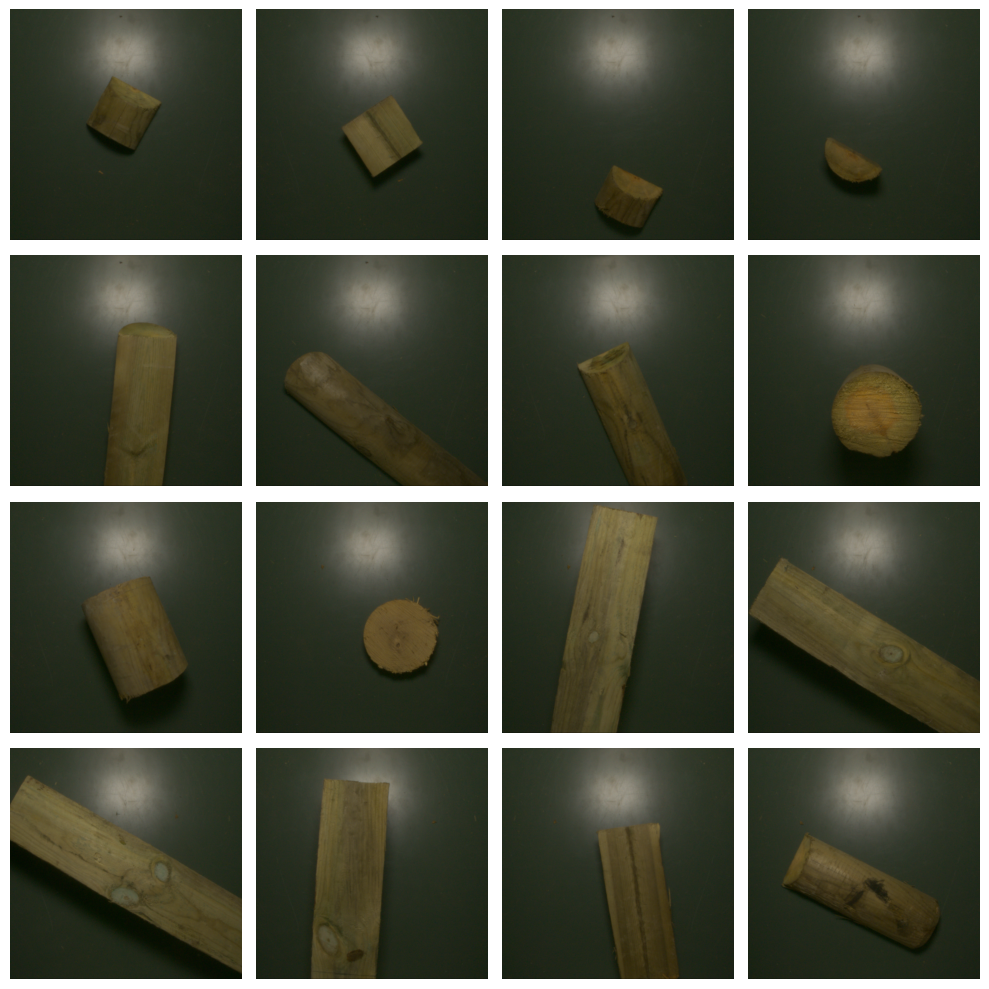

In [11]:
import numpy as np

import matplotlib.pyplot as plt

def preview_dataloader(dataloader, num_images=8):
    """
    Preview images from the dataloader in a grid.
    
    Args:
        dataloader: PyTorch DataLoader object
        num_images: Number of images to display (default: 8)
    """
    # Get a batch from the dataloader
    batch = next(iter(dataloader))
    images = batch["input"]
    
    # Limit to num_images
    images = images[:num_images]
    
    # Denormalize images from [-1, 1] to [0, 1]
    images = (images + 1) / 2
    images = torch.clamp(images, 0, 1)
    
    # Create grid
    grid_size = int(np.ceil(np.sqrt(num_images)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    axes = axes.flatten()
    
    for idx, ax in enumerate(axes):
        if idx < len(images):
            # Convert to numpy and transpose from CxHxW to HxWxC
            img = images[idx].permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Preview the dataloader
preview_dataloader(train_dataloader, num_images=16)